In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import os
os.environ['R_HOME'] = 'D:/Program Files/R-4.5.0' #@TODO include in some setup file

from simulation_engine.scenarios.iv.binary_iv import BinaryIV
from simulation_engine.scenarios.conf.binary_conf import BinaryConf
from simulation_engine.scenarios.iv.continuous_iv import ContinuousIV
from simulation_engine.util.plotting_util import PlottingUtil

import pandas as pd
pd.set_option('display.max_columns', None)

#disable warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import math
# from linearmodels.iv import IV2SLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neural_network import MLPClassifier
# Train a decision tree classifier to predict 'tightest_bounds'
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from simulation_engine.util.plotting_util import PlottingUtil
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np




In [2]:
binConf = pd.read_pickle('../binConf/17_06/results.pkl')
binIV = pd.read_pickle('../binIV/17_06/results.pkl')
contConf = pd.read_pickle('../contConf/17_06/results.pkl')
contIV = pd.read_pickle('../contIV/17_06/results.pkl')

In [3]:
bestAlg_ATE_binConf = PlottingUtil.compute_bestAlg(binConf, 'ATE', 0.01)    
bestAlg_ATE_binIV = PlottingUtil.compute_bestAlg(binIV, 'ATE', 0.01)
bestAlg_PNS_binConf = PlottingUtil.compute_bestAlg(binConf, 'PNS', 0.01)
bestAlg_PNS_binIV = PlottingUtil.compute_bestAlg(binIV, 'PNS', 0.01)
bestAlg_ATE_contConf = PlottingUtil.compute_bestAlg(contConf, 'ATE', 0.01)
bestAlg_ATE_contIV = PlottingUtil.compute_bestAlg(contIV, 'ATE', 0.01)

scenarios = {
    'BinaryConf': {'ATE': bestAlg_ATE_binConf['ATE_bestAlg'], 'PNS': bestAlg_PNS_binConf['PNS_bestAlg']},
    'BinaryIV': {'ATE': bestAlg_ATE_binIV['ATE_bestAlg'], 'PNS': bestAlg_PNS_binIV['PNS_bestAlg']},
    'ContConf': {'ATE': bestAlg_ATE_contConf['ATE_bestAlg']},
    'ContIV': {'ATE': bestAlg_ATE_contIV['ATE_bestAlg']}
}

## Best Alg: Prediction (Random Forest)

In [4]:
def compute_mutual_info(X, Y):
    """Compute mutual information between two arrays."""
    # Ensure X and Y are numpy arrays
    X = np.asarray(X)
    Y = np.asarray(Y)
    
    # Compute joint histogram
    joint_hist, _, _ = np.histogram2d(X, Y, bins=20)
    
    # Normalize to get joint probability distribution
    joint_prob = joint_hist / np.sum(joint_hist)
    
    # Compute marginal probabilities
    p_X = np.sum(joint_prob, axis=1)
    p_Y = np.sum(joint_prob, axis=0)
    
    # Compute mutual information
    mi = 0.0
    for i in range(len(p_X)):
        for j in range(len(p_Y)):
            if joint_prob[i, j] > 0:
                mi += joint_prob[i, j] * np.log(joint_prob[i, j] / (p_X[i] * p_Y[j]))
    
    return mi

In [5]:
# Select Dataframe and Query of your coices
tb = bestAlg_PNS_binConf.copy()
hasInstrument = False
target= 'PNS'

# compute mutual information for Z, X and Y
if(hasInstrument):
    tb['mutual_info_Z_X'] = tb.apply(lambda row: compute_mutual_info(row['Z'], row['X']), axis=1)
    tb['mutual_info_Z_Y'] = tb.apply(lambda row: compute_mutual_info(row['Z'], row['Y']), axis=1)
tb['mutual_info_X_Y'] = tb.apply(lambda row: compute_mutual_info(row['X'], row['Y']), axis=1)

if hasInstrument:
    feature_cols = [
        'entropy_Z',
        'entropy_X',
        'entropy_Y',
        'mutual_info_Z_X',
        'mutual_info_Z_Y',
        'mutual_info_X_Y',
    ]
else:
    feature_cols = [
        'entropy_X',
        'entropy_Y',
        'mutual_info_X_Y',
    ]

target_col = target+'_bestAlg'

X = pd.get_dummies(tb[feature_cols])
y = tb[target_col]

latex_map = {
    "entropy_Z":        r"$H(Z)$",
    "entropy_X":        r"$H(X)$",
    "entropy_Y":        r"$H(Y)$",
    "mutual_info_Z_X":  r"$I(Z,X)$",
    "mutual_info_Z_Y":  r"$I(Z,Y)$",
    "mutual_info_X_Y":  r"$I(X,Y)$",
}
latex_feature_names = [latex_map.get(col, col) for col in X.columns]

Classification Report:
                           precision    recall  f1-score   support

              causaloptim       0.00      0.00      0.00         2
       entropybounds-0.10       0.73      0.78      0.76       120
entropybounds-randomTheta       0.18      0.09      0.12        22
  entropybounds-trueTheta       0.75      0.86      0.80         7
           zaffalonbounds       0.87      0.88      0.88       249

                 accuracy                           0.81       400
                macro avg       0.51      0.52      0.51       400
             weighted avg       0.79      0.81      0.79       400

Accuracy: 0.81


C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

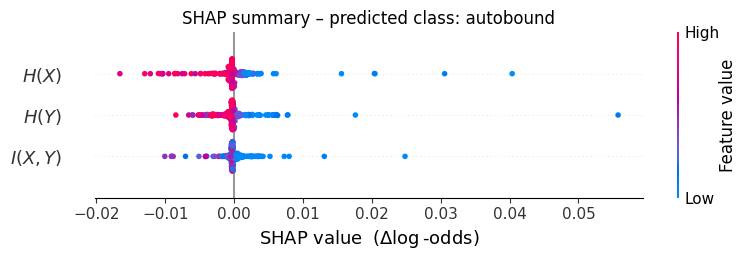

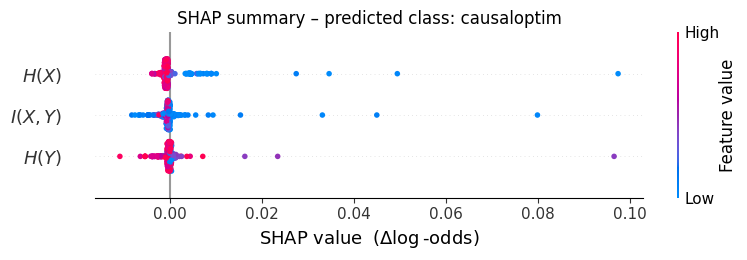

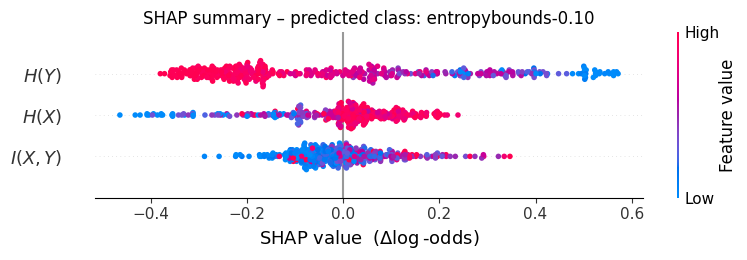

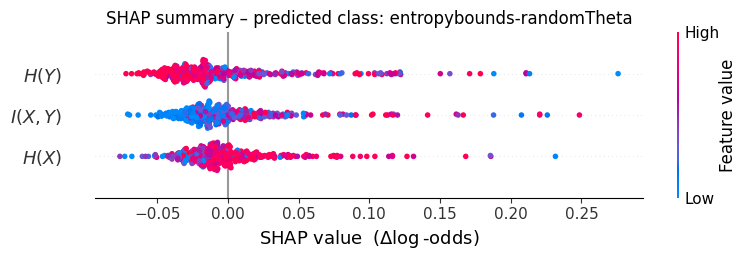

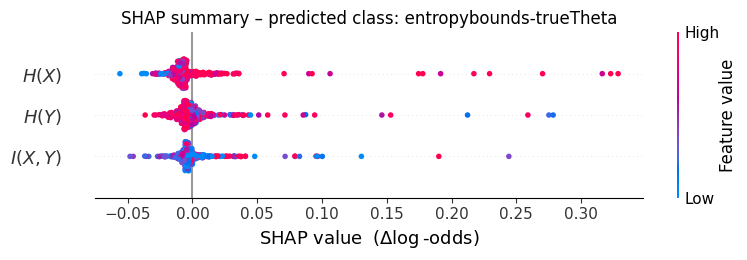

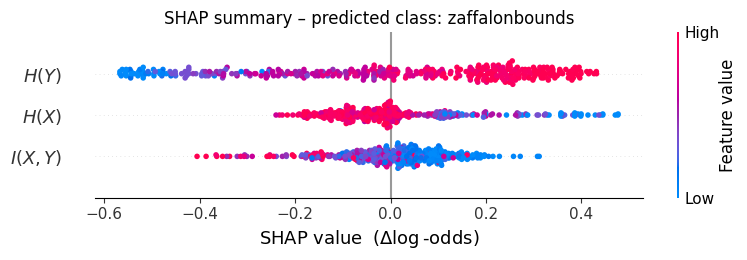

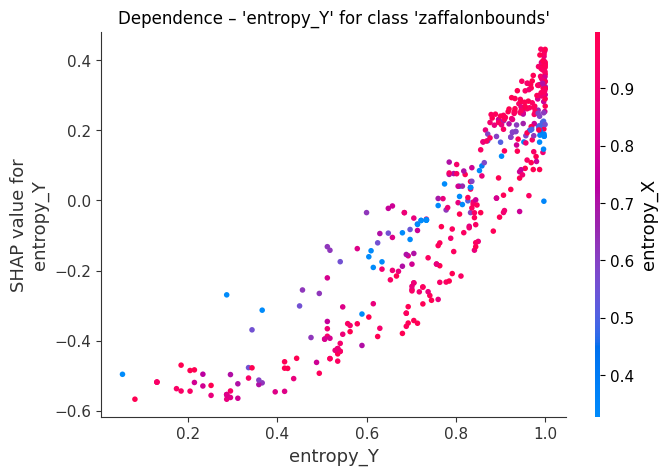

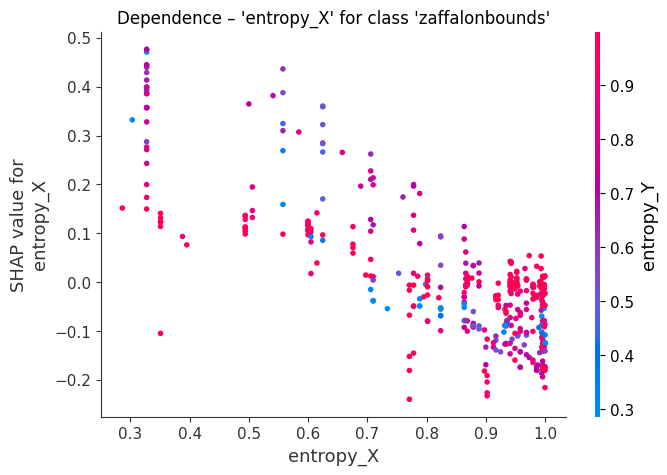

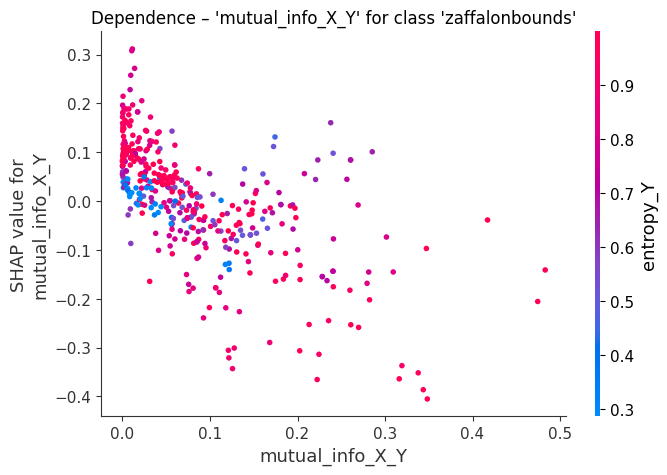


Signed mean SHAP values (positive → pushes probability up):
                           entropy_X  entropy_Y  mutual_info_X_Y
autobound                    -0.0001    -0.0001           0.0000
causaloptim                   0.0003     0.0000          -0.0001
entropybounds-0.10           -0.0145    -0.0026          -0.0037
entropybounds-randomTheta    -0.0007    -0.0001           0.0027
entropybounds-trueTheta       0.0003     0.0023           0.0006
zaffalonbounds                0.0148     0.0005           0.0004


In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_classifier.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# ---- SHAP Feature Importance (with direction) -------------------------------
import shap, matplotlib.pyplot as plt, pandas as pd, numpy as np

# 1) Build explainer and get SHAP values
explainer   = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test)           # ← may be list *or* 3-D array

# 2) Convert to list-of-arrays if needed
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # shape = (samples, features, classes)  →  list length = n_classes
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

assert isinstance(shap_values, list), "shap_values must now be a list of 2-D arrays"

class_names = rf_classifier.classes_
n_classes   = len(class_names)

# 3) Class-specific “dot” summary plots  (directional)
for i, cname in enumerate(class_names):
    shap.summary_plot(
        shap_values[i],                # (n_samples, n_features) for class i
        X_test,
        feature_names=latex_feature_names,
        plot_type="dot",
        show=False
    )
    plt.title(f"SHAP summary – predicted class: {cname}")
    plt.xlabel(r"SHAP value $\;(\Delta\log\text{-odds})$")
    plt.tight_layout()
    plt.show()

# 4) Dependence plots for the top-k features of the majority class
majority_label = pd.Series(y_train).value_counts().idxmax()
majority_idx   = list(class_names).index(majority_label)
top_k = 3

# pick the top-k features (by |SHAP|) for that class
abs_shap = np.abs(shap_values[majority_idx]).mean(axis=0)    # vector length = n_features
top_feat_idx = abs_shap.argsort()[::-1][:top_k]

for idx in top_feat_idx:
    feat_name = X.columns[idx]
    shap.dependence_plot(
        feat_name,                          # just the feature name (or index)
        shap_values[majority_idx],          # 2-D SHAP matrix for *this* class
        X_test,
        feature_names=X.columns,
        show=False
    )
    plt.title(f"Dependence – '{feat_name}' for class '{majority_label}'")
    plt.show()

# 5) Signed mean SHAP table (quick numeric view)
signed_mean = {
    cname: pd.Series(shap_values[i].mean(0), index=X.columns)
    for i, cname in enumerate(class_names)
}
print("\nSigned mean SHAP values (positive → pushes probability up):")
print(pd.DataFrame(signed_mean).T.round(4))


## Best Alg: Plotting

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Flatten to dataframe
data = []
for scenario, results in scenarios.items():
    for query_type, series in results.items():
        counter = Counter(series)
        total = len(series)
        for alg, count in counter.items():
            data.append({
                'Scenario': scenario,
                'Query': query_type,
                'Algorithm': alg,
                'Count': count,
                'Fraction': count / total
            })
df = pd.DataFrame(data)


# Flatten to dataframe, grouping all binned variants under one name
# data = []
# for scenario, results in scenarios.items():
#     for query_type, series in results.items():
#         counter = Counter(series)
#         total = len(series)
#         for alg, count in counter.items():
#             # Group binned algorithms under a shared label
#             if isinstance(alg, str) and alg.endswith("--binned"):
#                 alg_name = "Using discretized Data"
#             else:
#                 alg_name = alg if alg is not None else "Unknown"
#             data.append({
#                 'Scenario': scenario,
#                 'Query': query_type,
#                 'Algorithm': alg_name,
#                 'Count': count,
#                 'Fraction': count / total
#             })

# # Create DataFrame
# df = pd.DataFrame(data)

# # Aggregate any duplicates (e.g., multiple binned methods grouped under one name)
# df = df.groupby(['Scenario', 'Query', 'Algorithm'], as_index=False)['Count'].sum()
# df['Fraction'] = df.groupby(['Scenario', 'Query'])['Count'].transform(lambda x: x / x.sum())

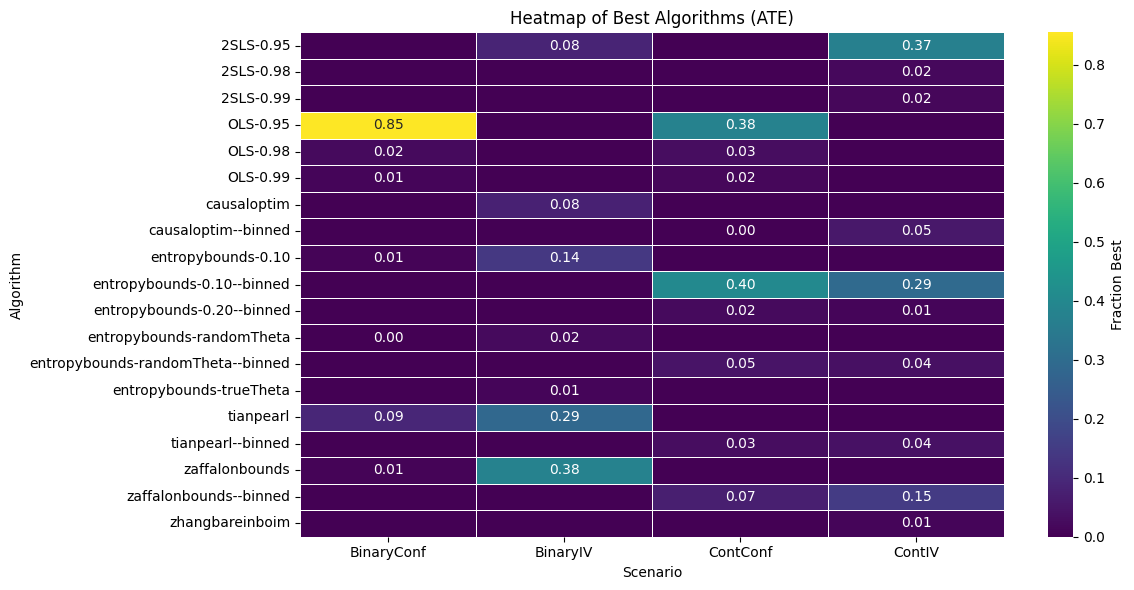

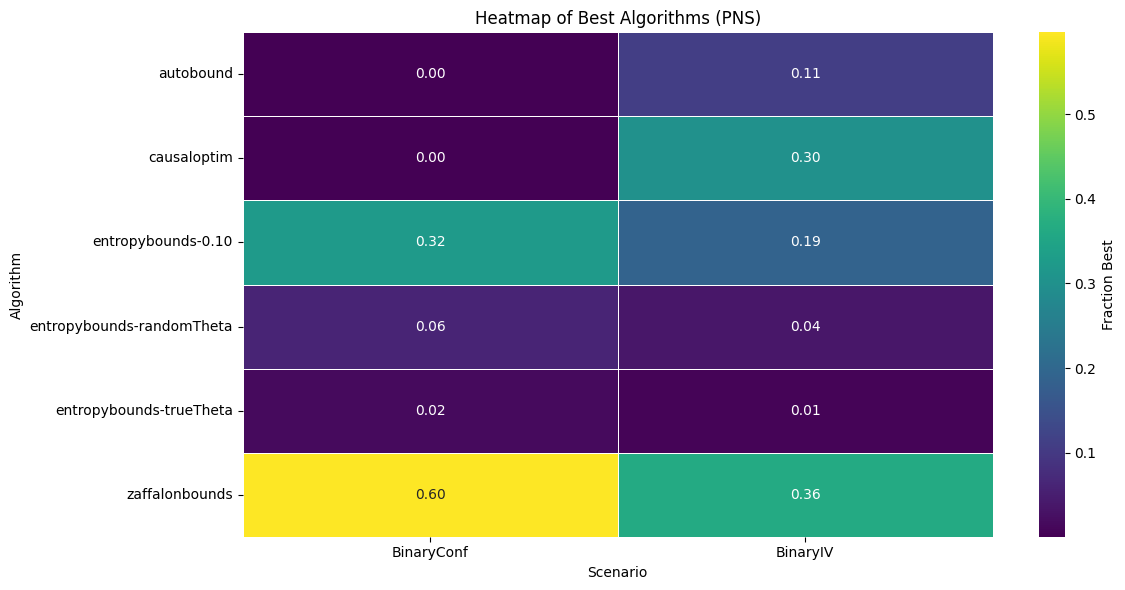

In [9]:
# TWO Heatmaps
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Assumes you already have a DataFrame `df` structured like this:
# Columns: ['Scenario', 'Query', 'Algorithm', 'Count', 'Fraction']

# Create separate Scenario_Query column for labeling
df_ate = df[df['Query'] == 'ATE'].copy()
df_pns = df[df['Query'] == 'PNS'].copy()

df_ate['Scenario_Query'] = df_ate['Scenario']
df_pns['Scenario_Query'] = df_pns['Scenario']

# Pivot tables for heatmap
heatmap_ate = df_ate.pivot_table(index='Algorithm', columns='Scenario_Query', values='Fraction', fill_value=0)
heatmap_pns = df_pns.pivot_table(index='Algorithm', columns='Scenario_Query', values='Fraction', fill_value=0)

# Filter out rows with only zeros
heatmap_ate = heatmap_ate[(heatmap_ate > 0.01).any(axis=1)]
heatmap_pns = heatmap_pns[(heatmap_pns > 0.01).any(axis=1)]

# Create annotation masks (hide 0s)
annot_ate = heatmap_ate.applymap(lambda x: f"{x:.2f}" if x > 0 else "")
annot_pns = heatmap_pns.applymap(lambda x: f"{x:.2f}" if x > 0 else "")

# Plot ATE heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_ate, annot=annot_ate, cmap='viridis', fmt='', linewidths=0.5, cbar_kws={'label': 'Fraction Best'})
plt.title('Heatmap of Best Algorithms (ATE)')
plt.xlabel('Scenario')
plt.ylabel('Algorithm')
plt.tight_layout()
plt.show()

# Plot PNS heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_pns, annot=annot_pns, cmap='viridis', fmt='', linewidths=0.5, cbar_kws={'label': 'Fraction Best'})
plt.title('Heatmap of Best Algorithms (PNS)')
plt.xlabel('Scenario')
plt.ylabel('Algorithm')
plt.tight_layout()
plt.show()


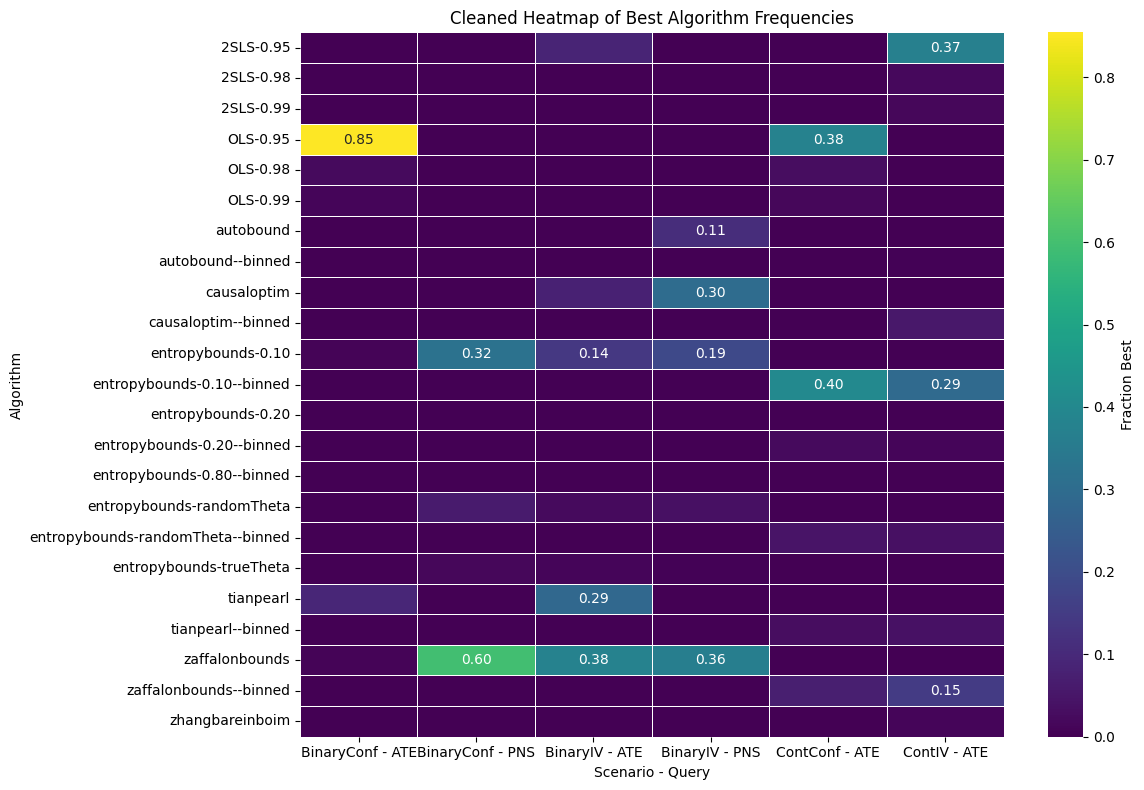

In [ ]:
# ONE Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pivot table suitable for a heatmap: rows=Algorithm, columns=Scenario_Query, values=Fraction
df['Scenario_Query'] = df['Scenario'] + ' - ' + df['Query']
heatmap_data = df.pivot_table(index='Algorithm', columns='Scenario_Query', values='Fraction', fill_value=0)

# Filter to only algorithms that are best at least once
heatmap_data = heatmap_data[(heatmap_data > 0).any(axis=1)]

# Custom annotation: blank if zero
annot = heatmap_data.applymap(lambda x: f"{x:.2f}" if x > 0.1 else "")

# Plot cleaned heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, annot=annot, cmap='viridis', fmt='',
    linewidths=0.5, cbar_kws={'label': 'Fraction Best'}
)
plt.title('Cleaned Heatmap of Best Algorithm Frequencies')
plt.xlabel('Scenario - Query')
plt.ylabel('Algorithm')
plt.tight_layout()
plt.show()


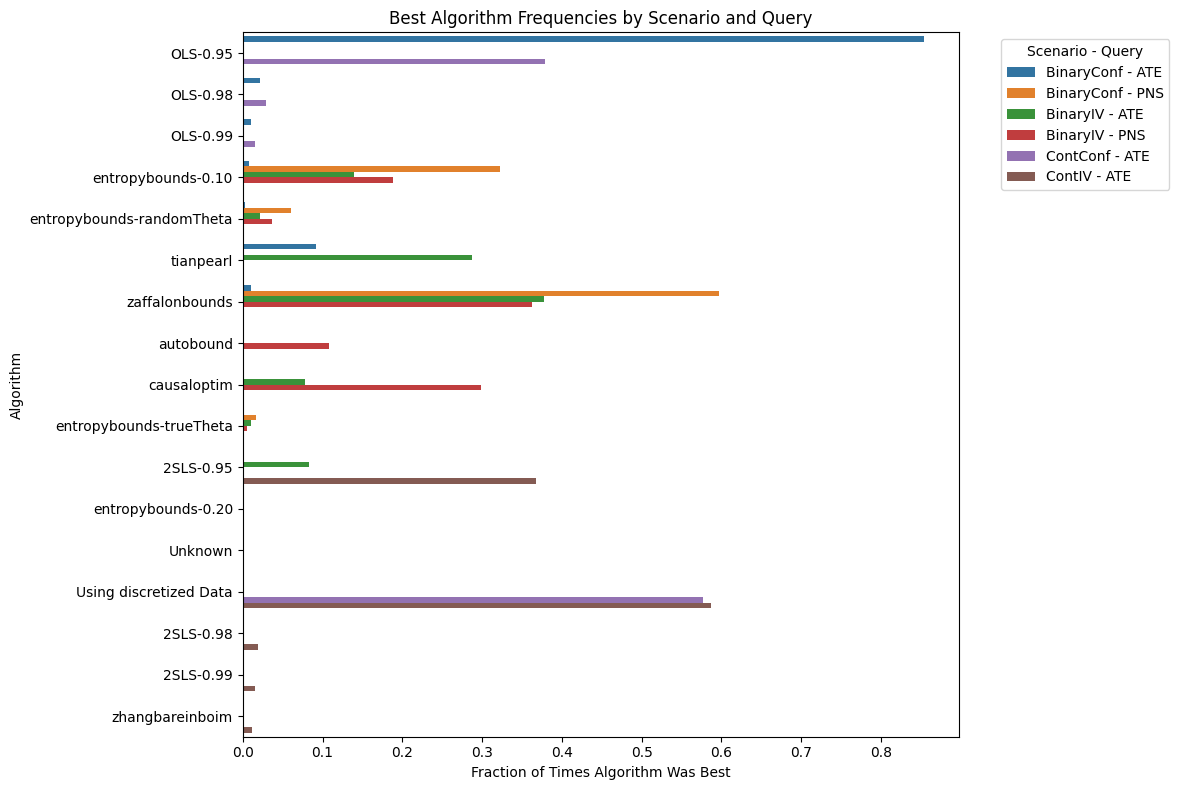

In [ ]:
# Horizontal bar plot
df['Scenario_Query'] = df['Scenario'] + ' - ' + df['Query']

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df,
    y='Algorithm',
    x='Fraction',
    hue='Scenario_Query',
    orient='h'
)

# Styling
plt.title('Best Algorithm Frequencies by Scenario and Query')
plt.xlabel('Fraction of Times Algorithm Was Best')
plt.ylabel('Algorithm')
plt.legend(title='Scenario - Query', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\tmari\AppData\Local\Temp\ipykernel_16064\1836988827.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(algorithm_list))
C:\Users\tmari\AppData\Local\Temp\ipykernel_16064\1836988827.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


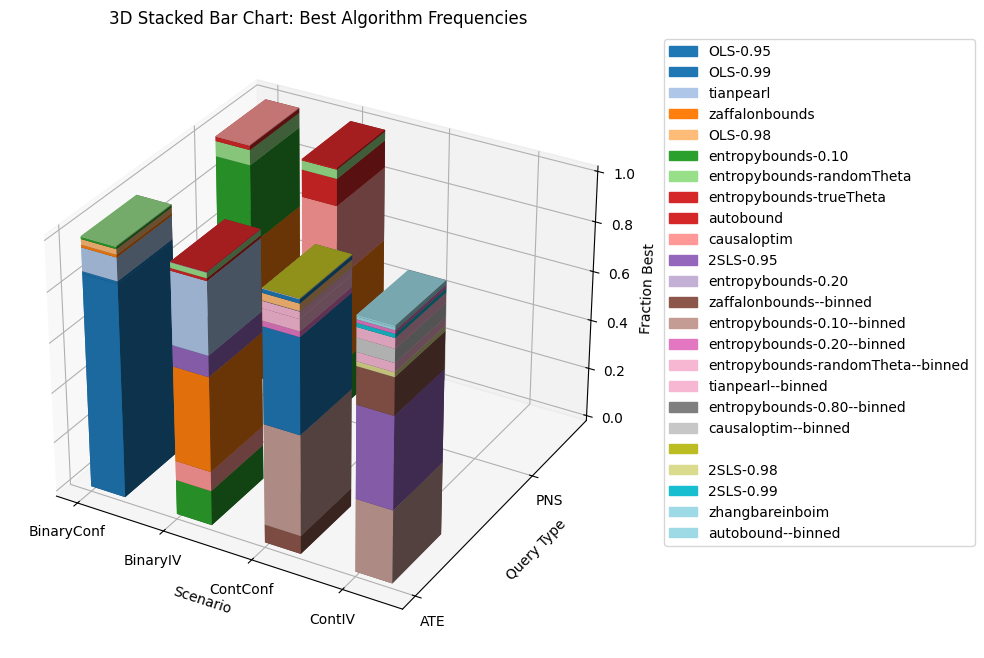

In [ ]:
### Useless 3D Plot
# Mappings
scenarios_list = df['Scenario'].unique()
scenario_map = {s: i for i, s in enumerate(scenarios_list)}
query_map = {'ATE': 0, 'PNS': 1}
algorithm_list = df['Algorithm'].unique()
algorithm_map = {alg: i for i, alg in enumerate(algorithm_list)}

# Colormap
colors = cm.get_cmap('tab20', len(algorithm_list))

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

dx = 0.4
dy = 0.4

# Group by scenario and query, then stack fractions
for (scenario, query), group in df.groupby(['Scenario', 'Query']):
    x = scenario_map[scenario]
    y = query_map[query]
    bottom = 0
    for _, row in group.iterrows():
        dz = row['Fraction']
        color = colors(algorithm_map[row['Algorithm']])
        ax.bar3d(x, y, bottom, dx, dy, dz, color=color, shade=True)
        bottom += dz

# Axis formatting
ax.set_xlabel('Scenario')
ax.set_ylabel('Query Type')
ax.set_zlabel('Fraction Best')
ax.set_xticks(list(scenario_map.values()))
ax.set_xticklabels(list(scenario_map.keys()))
ax.set_yticks(list(query_map.values()))
ax.set_yticklabels(list(query_map.keys()))
ax.set_title('3D Stacked Bar Chart: Best Algorithm Frequencies')

# Optional: Add color legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=colors(algorithm_map[alg]), label=alg) for alg in algorithm_list]
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [80]:
#create new df that only contains best algorithms and scenario description
# Compute row-wise correlation between X and Y (which are lists/arrays per row)


bestAlg_ATE_binConf_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_binConf['ATE_bestAlg'],
    'Instrument': False,
    'Contiunous': False,
    # 'entropy_X': bestAlg_ATE_binConf['entropy_X'],
    # 'entropy_U': bestAlg_ATE_binConf['entropy_U'],
    # 'entropy_Y': bestAlg_ATE_binConf['entropy_Y'],
    # 'corr_XY': bestAlg_ATE_binConf.apply(lambda row: np.corrcoef(row['X'], row['Y'])[0, 1], axis=1)
})

bestAlg_ATE_binIV_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_binIV['ATE_bestAlg'],
    'Instrument': True,
    'Contiunous': False,
})

bestAlg_ATE_contConf_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_contConf['ATE_bestAlg'],
    'Instrument': False,
    'Contiunous': True,
})

bestAlg_ATE_contIV_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_contIV['ATE_bestAlg'],
    'Instrument': True,
    'Contiunous': True,
})

## Combine all the simple dataframes into one
bestAlg_ATE_simple = pd.concat([
    bestAlg_ATE_binConf_simple,
    bestAlg_ATE_binIV_simple,
    bestAlg_ATE_contConf_simple,
    bestAlg_ATE_contIV_simple
], ignore_index=True)

# Drop rows where ATE_bestAlg is None or NaN
filtered = bestAlg_ATE_simple.dropna(subset=['ATE_bestAlg'])

#train a decision tree classifier to predict bestAlg
X = filtered[['Instrument', 'Contiunous']]
y = filtered['ATE_bestAlg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


                                   precision    recall  f1-score   support

                        2SLS-0.95       0.38      0.82      0.52       180
                        2SLS-0.98       0.00      0.00      0.00         4
                        2SLS-0.99       0.00      0.00      0.00         5
                         OLS-0.95       0.87      0.69      0.77       528
                         OLS-0.98       0.00      0.00      0.00        22
                         OLS-0.99       0.00      0.00      0.00        10
                autobound--binned       0.00      0.00      0.00         2
                      causaloptim       0.00      0.00      0.00        34
              causaloptim--binned       0.00      0.00      0.00        21
               entropybounds-0.10       0.00      0.00      0.00        56
       entropybounds-0.10--binned       0.38      0.59      0.46       260
               entropybounds-0.20       0.00      0.00      0.00         1
       entropybounds-0.2

C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [84]:
bestAlg_ATE_binConf_simple['ATE_bestAlg'].value_counts()

ATE_bestAlg
OLS-0.95                     1709
tianpearl                     184
OLS-0.98                       44
OLS-0.99                       21
zaffalonbounds                 20
entropybounds-0.10             16
entropybounds-randomTheta       6
Name: count, dtype: int64